In [115]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf

## 3.1 DATA FETCHING
Read the data and plot the three non-lagged time series (Ph,Tdelta,Gv). Describe the time series
and if you can see some dependencies between the variables.

In [116]:
df = pd.read_csv("data/box_data_60min.csv")
df.head()

,thour,tdate,Ph,Tdelta,Gv,Ph.l0,Ph.l1,Ph.l2,Ph.l3,Ph.l4,...,Gv.l1,Gv.l2,Gv.l3,Gv.l4,Gv.l5,Gv.l6,Gv.l7,Gv.l8,Gv.l9,Gv.l10
0,19,2013-01-30 02:00:00,56,13.253583,-0.498643,56,55,57,57,58,...,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339,20.475484
1,20,2013-01-30 03:00:00,54,13.181458,-1.127035,54,56,55,57,57,...,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339
2,21,2013-01-30 04:00:00,55,12.968792,-0.643298,55,54,56,55,57,...,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700
3,22,2013-01-30 05:00:00,54,12.667750,-0.456008,54,55,54,56,55,...,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776
4,23,2013-01-30 06:00:00,54,12.605250,-1.534060,54,54,55,54,56,...,-0.456008,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267


In [117]:
df.describe()

,thour,Ph,Tdelta,Gv,Ph.l0,Ph.l1,Ph.l2,Ph.l3,Ph.l4,Ph.l5,...,Gv.l1,Gv.l2,Gv.l3,Gv.l4,Gv.l5,Gv.l6,Gv.l7,Gv.l8,Gv.l9,Gv.l10
count,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,...,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000
mean,134.000000,74.709957,20.636638,51.246370,74.783550,74.770563,74.926407,74.900433,74.900433,74.826840,...,50.714305,47.949382,46.870573,45.927411,44.778637,44.501627,44.329465,44.283781,44.318730,44.407650
std,66.828138,18.025292,3.310936,122.629162,17.904964,17.918273,17.602340,17.624428,17.624428,17.655283,...,122.585691,116.318231,115.599021,115.089166,114.217872,114.250300,114.288103,114.303828,114.291521,114.264827
min,19.000000,14.000000,12.573000,-2.226486,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486
25%,76.500000,67.000000,18.252792,-0.650363,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,...,-0.650363,-0.650363,-0.650363,-0.650363,-0.672537,-0.678456,-0.678456,-0.678456,-0.678456,-0.678456
50%,134.000000,76.000000,21.375875,-0.169945,76.000000,76.000000,76.000000,76.000000,76.000000,75.000000,...,-0.178408,-0.198030,-0.200307,-0.205313,-0.210594,-0.215003,-0.215714,-0.215714,-0.215714,-0.215714
75%,191.500000,88.500000,23.547583,26.806097,88.500000,88.500000,88.500000,88.500000,88.500000,88.500000,...,25.872586,25.029070,23.822901,22.318112,21.175614,20.361604,20.156048,20.156048,20.156048,20.321019
max,249.000000,98.000000,25.444333,876.008527,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,...,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527


We can see that there are 231 observations, mean and std are described. We look at the first three columns, which have no missing values: as magnitude differs significantly for each case, we plot them separately.

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fb/wkd3ltnj40qb6km7wd9gfdz40000gn/T/ipykernel_5626/1317077745.py:10: SyntaxWarning: invalid escape sequence '\c'
  axes[1].set_ylabel('Temp ($^\circ$C)')


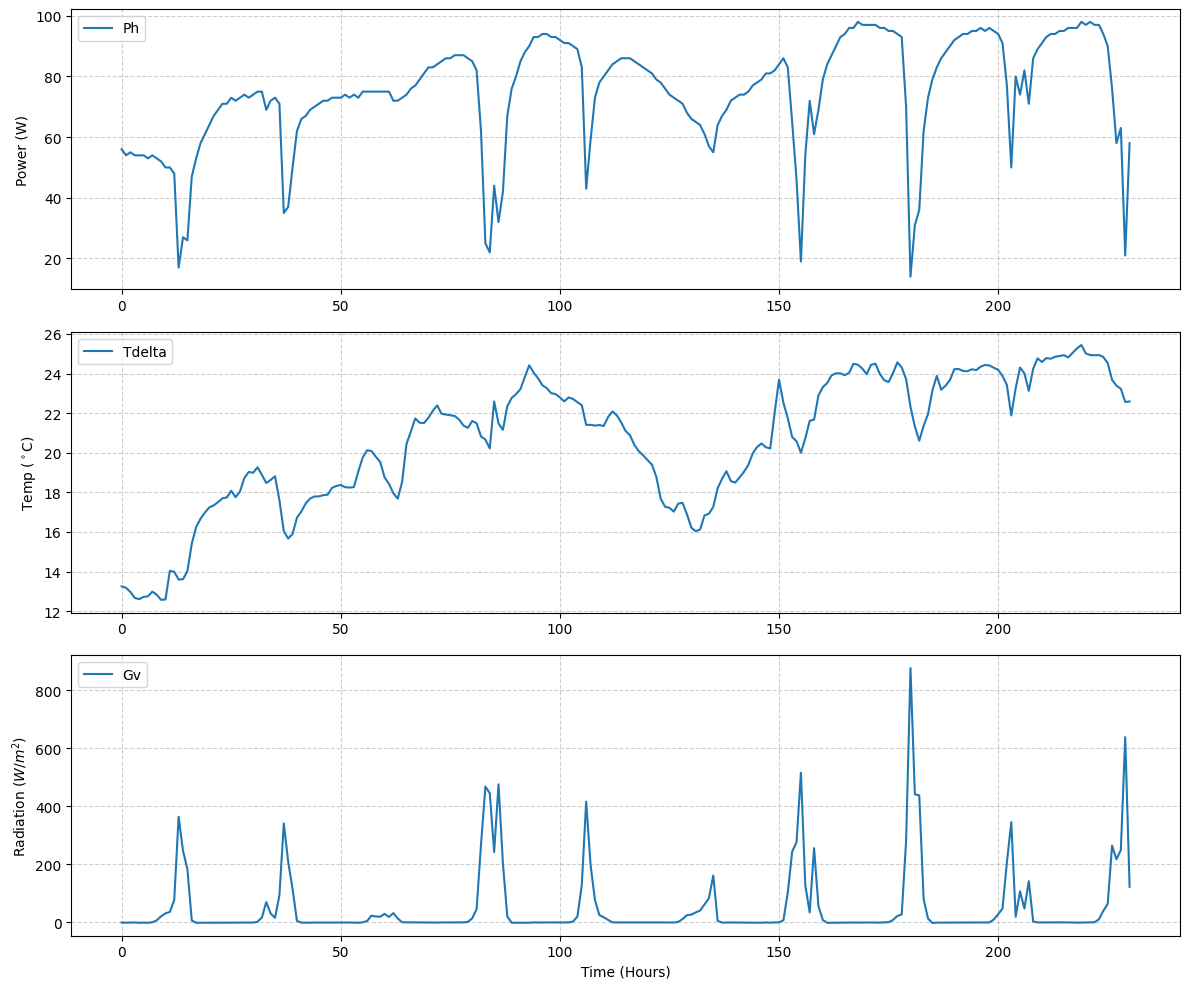

In [118]:
fig, axes = plt.subplots(3, 1, figsize= (12,10))

axes[0].plot(df['Ph'], label = 'Ph')
axes[0].grid(True, linestyle='--', alpha=0.6) 
axes[0].set_ylabel('Power (W)')
axes[0].legend(loc = 'upper left')

axes[1].plot(df['Tdelta'], label = 'Tdelta')
axes[1].grid(True, linestyle='--', alpha=0.6) 
axes[1].set_ylabel('Temp ($^\circ$C)')
axes[1].legend()

axes[2].plot(df['Gv'], label = 'Gv')
axes[2].grid(True, linestyle='--', alpha=0.6) 
axes[2].set_ylabel('Radiation ($W/m^2$)')
axes[2].set_xlabel('Time (Hours)')
axes[2].legend(loc = 'upper left')

plt.tight_layout()
plt.savefig("plot_ex3/exercise_1.svg", format='svg', bbox_inches='tight')
plt.show()

The last plot is the most interpretable, as it represents solar radiations, it shows peaks during daylight and it has seasonality of 24 hours.
Correspondingly to these spikes, the heating Power dips down.
This reflects the thermostatic control compensating for solar heat gains.
Additionally, Tdelta shows a positive relationship with Ph, because a higher temperature gradient represents a larger heating load that the electrical heaters must compensate for.

## 3.2 SPLIT DATA
Split the data into a train and test set, such that ”2013-02-06 00:00” is the last data point in the
training set (i.e. thour = 1,...,167 is the training set). From now on, work only on the training
set, except where explicitly told to use the test set

In [119]:
df_train = df[df['thour'] < 168]
df_test = df[df['thour'] > 167]

## 3.3 DATA INVESTIGATION
Investigate the variables and their relations: e.g. with scatter, auto-correlation and cross-correlation
plots. Most focus on Ph. Highlight key aspects of the dynamics and interrelationships among
the variables. What can be seen directly and what cannot?

Since our aim is to predict the correct Ph, the following investigations will have Ph as the dependent variable

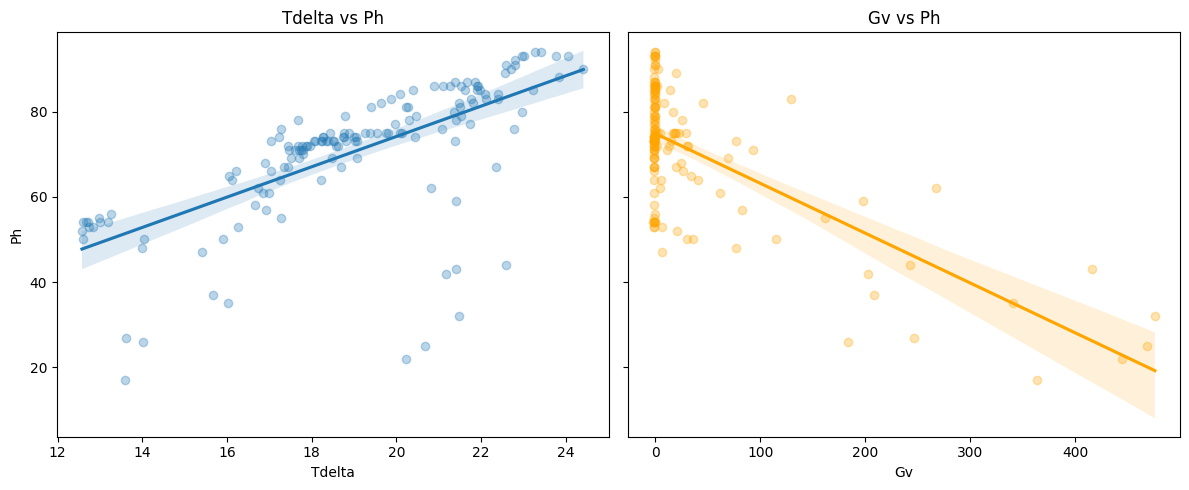

In [120]:
# scatter
# we use regplot from seaborn bcs it automatically calculates regression lines
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.regplot(data=df_train, x='Tdelta', y='Ph', ax=ax[0], scatter_kws={'alpha':0.3})
ax[0].set_title('Tdelta vs Ph')
sns.regplot(data=df_train, x='Gv', y='Ph', ax=ax[1], scatter_kws={'alpha':0.3}, color='orange')
ax[1].set_title('Gv vs Ph')
ax[1].set_ylabel('') # Hidden by sharey, but good to keep clean
ax[0].set_ylabel('Ph')
plt.tight_layout()
plt.savefig("plot_ex3/exercise_21.svg", format='svg', bbox_inches='tight')
plt.show()

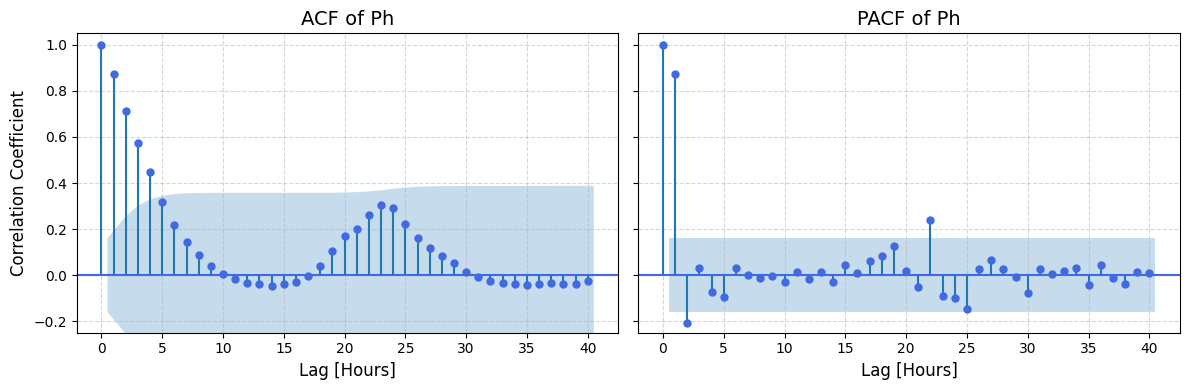

In [121]:
# auto-correlation rho
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey= True)
plot_acf(df_train['Ph'], lags = 40, ax=ax[0], color='royalblue')
ax[0].set_title('ACF of Ph', fontsize=14)
ax[0].set_xlabel('Lag [Hours]', fontsize=12)
ax[0].set_ylabel('Correlation Coefficient', fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.5)

plot_pacf(df_train['Ph'], lags = 40, ax=ax[1], color='royalblue')
ax[1].set_title('PACF of Ph', fontsize=14)
ax[1].set_xlabel('Lag [Hours]', fontsize=12)
# No need to set ylabel for ax[1] since sharey=True
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.ylim(-0.25, 1.05)
plt.tight_layout()

# Save and show
plt.savefig("plot_ex3/exercise_22.svg", format='svg', bbox_inches='tight')
plt.show()

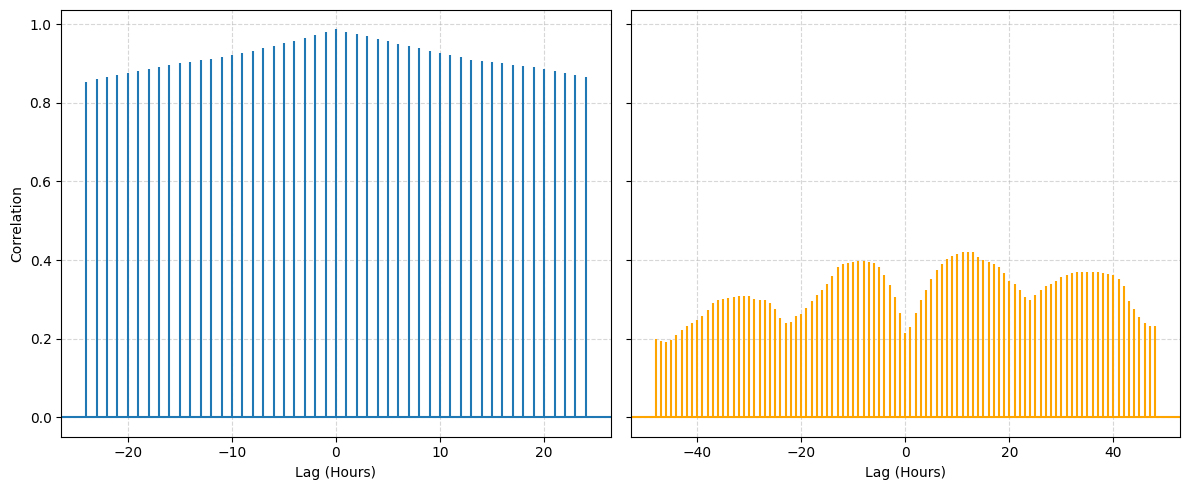

In [122]:
#cross-correlation
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# CCF: Temperature (Tdelta) vs Heating (Ph)
ax[0].xcorr(df_train['Ph'], df_train['Tdelta'], maxlags=24)
ax[0].set_xlabel('Lag (Hours)')
ax[0].grid(True, linestyle='--', alpha=0.5)

# CCF: Solar (Gv) vs Heating (Ph)
# we put 48h lags to see periodicity
ax[1].xcorr(df_train['Ph'], df_train['Gv'], maxlags=48, color='orange')
ax[1].set_xlabel('Lag (Hours)')
ax[1].grid(True, linestyle='--', alpha=0.5)

ax[0].set_ylabel('Correlation')
plt.tight_layout()
plt.savefig("plot_ex3/exercise_23.svg", format='svg', bbox_inches='tight')
plt.show()

ACF shows damped exponentials, so we exclude the process to be a purely MA(q) model. Instead, this behaviour suggests an AR component.

Looking at cross correlation:
1. Tdelta vs Ph shows an extremely high positive correlation (near 1.0) centered at Lag 0, so that the temperature difference is the primary driver of heating power. Also, the bars stay very high for all 15 lags, which means that the two variables remain correlated also for significant lags in time. In other terms, we can say that Tdelta is highly autocorrelated.
2. Gv vs Ph shows that the relationship between solar radiation andd heating is a repeating cycle of 24 hours. At Lag 0 we find a local minimum of approximately 0.2. While we expect a physical negative dependency (solar gain reducing heating), the raw CCF remains positive. We can interpret this as an uncorrelation between the tempreature being high, and the sun shining (it can happen the other way around) and a strong dominance of the temperature gradient (T delta).

## 3.4 IMPULSE RESPONSE
Estimate the impulse response from Tdelta and Gv to Ph make it up to lag 10. Present it for both variables in plots and comment.

First of all, the impulse response function exists for every linear and time invariant system (Theorem 4.1).
In our case, we have found a linear relation from the scatter plots between Ph and GV, and Ph and Tdelta, so we can assume the system to be linear. Also we can assume it is time-invariant in the sense of the Def 4.2 because the physical properties of the box and the operational behaviour of the thermostat are constant over the period of the experiment: so a specific weather pattern will result in the same heating response at any time it occurs during the study.

We therefore search the impulse response in the form of Theorem 4.1.
$$P_{h,t} = \sum_{k=0}^{10} h_{k}^{(T)} T_{delta,t-k} + \sum_{k=0}^{10} h_{k}^{(G)} G_{v,t-k} + \epsilon_t$$

LS estimates - based on the assumption that noise is white noise.
ML estimates - based on the assumption of normality in the noise.
Both unweighted, so they should be used only if the variance of the residuals is constant and residuals are mutually independent. We can assume physical/environmental conditions do not change, so variance of residuals remains the same during the experiment.

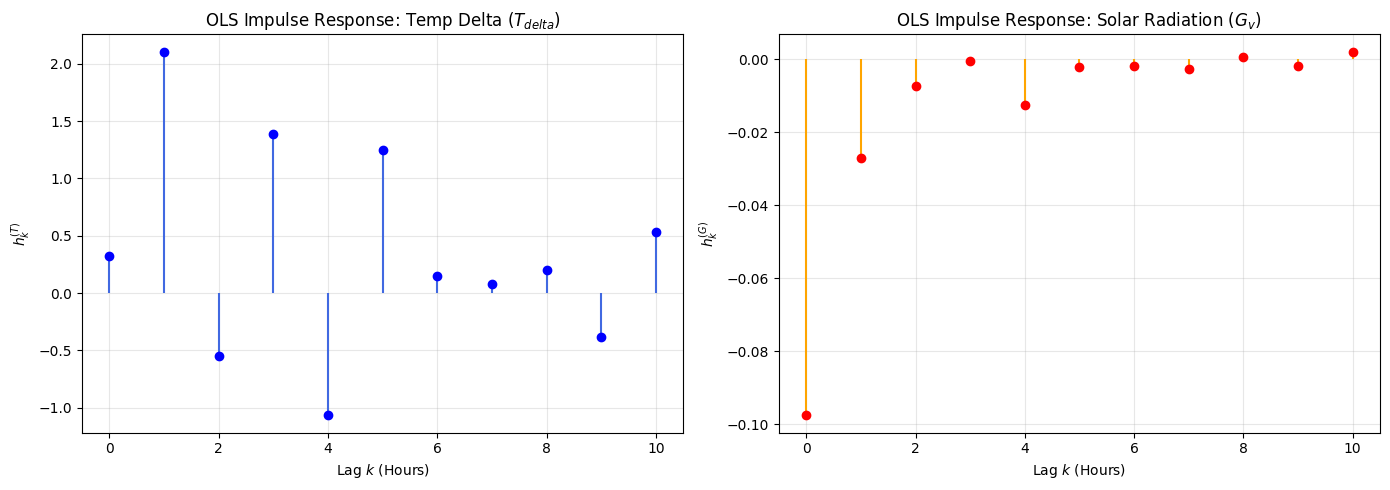

                                 OLS Regression Results                                
Dep. Variable:                     Ph   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                              8222.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):                   3.53e-189
Time:                        10:58:31   Log-Likelihood:                         -308.18
No. Observations:                 149   AIC:                                      660.4
Df Residuals:                     127   BIC:                                      726.5
Df Model:                          22                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [123]:
# columns for the lags (0 to 10)
gv_cols = [f'Gv.l{i}' for i in range(11)]
tdelta_cols = [f'Tdelta.l{i}' for i in range(11)]
X_cols = gv_cols + tdelta_cols

X = df_train[X_cols]
y = df_train['Ph']

# We fit the model using Maximum Likelihood
# We use order=(0,0,0) bcs we already input the correct variables X
# no seasonality, lag 10 < 24h
model = sm.tsa.statespace.SARIMAX(y, exog=X, order=(0, 0, 0))

# We fit the model using OLS
model = sm.OLS(y, X)
results = model.fit()

# results.params contains the estimated weights for each lag
h_G = [results.params[col] for col in gv_cols]
h_T = [results.params[col] for col in tdelta_cols]


# Plotting the Impulse Response
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Temperature Difference Response
ax[0].stem(range(11), h_T, basefmt=" ", linefmt='royalblue', markerfmt='ob')
ax[0].set_title('OLS Impulse Response: Temp Delta ($T_{delta}$)')
ax[0].set_xlabel('Lag $k$ (Hours)')
ax[0].set_ylabel('$h_k^{(T)}$')
ax[0].grid(True, alpha=0.3)

# Solar Radiation Response
ax[1].stem(range(11), h_G, basefmt=" ", linefmt='orange', markerfmt='or')
ax[1].set_title('OLS Impulse Response: Solar Radiation ($G_v$) ')
ax[1].set_xlabel('Lag $k$ (Hours)')
ax[1].set_ylabel('$h_k^{(G)}$')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_ex3/exercise_4.svg", format='svg', bbox_inches='tight')
plt.show()

# Print the summary to check Log-Likelihood and AIC
print(results.summary())

Solar Radiation ($G_v$) 
As physically expected, the estimated impulse response weights ($h_k^{(G)}$) are predominantly **negative**, confirming that solar gain reduces the required heating power. 
* **Significance**: Only the first two lags ($k=0, 1$) are statistically significant ($p < 0.05$). This indicates that the primary cooling effect of solar radiation is immediate. 
* **Noise at High Lags**: The minor positive values at lags 8 and 9 are statistically insignificant ($p > 0.05$) and can be attributed to stochastic noise or diurnal confounding effects that occur far from the initial impulse.

Temperature Difference ($T_{delta}$)
The response for the temperature gradient oscillates but remains largely positive, as increased heat loss to the environment requires higher power input. 
* **Physical Delay**: Notably, the response at **Lag 1** is significantly stronger and more certain ($p < 0.001$) than at Lag 0. This characterizes the **thermal inertia** and insulation properties of the test box, representing the time required for external temperature changes to conduct through the envelope and affect the internal thermostat.



Residual Diagnostics (Ljung-Box)
The Ljung-Box test yields a high statistic ($Q = 24.02$) with a p-value of $0.00$. This results in a formal **rejection of the white noise hypothesis** for the residuals. 
* **Implication**: Such a significant result indicates that the current FIR (Finite Impulse Response) model fails to capture the internal dynamics of the system. The remaining pattern in the residuals suggests **serial correlation**, likely due to the "memory" of the internal air temperature. 
* **Conclusion**: This diagnostic failure justifies the transition to a parametric **ARX model** in the following section to properly account for these autoregressive dependencies.

I wouldnt trust the forecast

## 3.5 LINEAR REGRESSION MODEL
Fit the linear regression model
$$
P_{h,t} = ω_1 T_{delta,t} + ω_2 G_{v,t} + ε_t
$$
The error is assumed εt ∼N(0,σ2) and i.i.d.
Analyse the estimation result, one-step prediction, residuals with plots, ACF and CCF. Comment
with focus on the potential need for a model which includes a transfer function.

In [124]:
# We add a "Control" variable (Pure White Noise)
# We want to see if it works
np.random.seed(42)
df_train['white_noise'] = np.random.normal(0, 1, size=len(df_train))

X_cols = ['Tdelta', 'Gv', 'white_noise']
X = df_train[X_cols]
y = df_train['Ph']

# Add a constant: this sets a baseline for Pv so it doesn't 
# necessarily need to be == 0 when Tdelta = Gv = 0
X = sm.add_constant(X)

# 4. Fit the ML model
model_ml = sm.tsa.statespace.SARIMAX(y, exog=X, order=(0, 0, 0))
results = model_ml.fit(disp=False)

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                     Ph   No. Observations:                  149
Model:                        SARIMAX   Log Likelihood                -447.042
Date:                Tue, 14 Apr 2026   AIC                            904.084
Time:                        10:58:31   BIC                            919.104
Sample:                             0   HQIC                           910.186
                                - 149                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           9.8324      2.984      3.295      0.001       3.984      15.681
Tdelta          3.4185      0.152     22.520      0.000       3.121       3.716
Gv             -0.1130      0.003    -33.109    

Both weather variables have p<0.001, while white_noise has p=0.780. This proves the model is correctly identifying physical signal over random noise.
But we notice that the Ljung-Box statistic has a value even higher than in the previous case. This suggests that by ignoring the "history" of the inputs (the transfer function), the model's accuracy has dropped significantly.

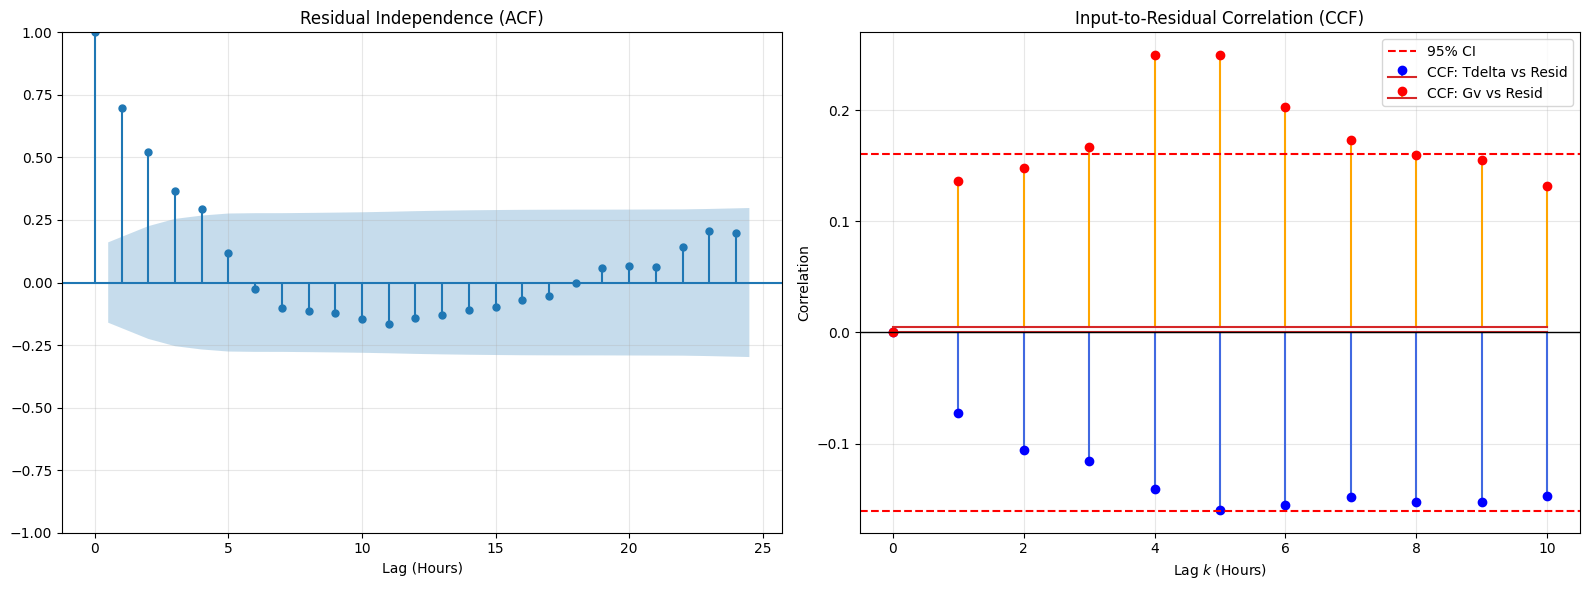

In [125]:
# Extract residuals
residuals = results.resid
n_obs = len(df_train)
conf_level = 1.96 / np.sqrt(n_obs) #from the theory, 95% confidence in gaussian distribution

# ccf(x, y) correlates x_past with y_now
ccf_tdelta = ccf(df_train['Tdelta'], residuals, adjusted=False)[:11]
ccf_gv = ccf(df_train['Gv'], residuals, adjusted=False)[:11]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  ACF
plot_acf(residuals, lags=24, ax=axes[0], title='Residual Independence (ACF)')
axes[0].set_xlabel('Lag (Hours)')
axes[0].grid(True, alpha=0.3)

#  CCF
axes[1].stem(range(11), ccf_tdelta, linefmt='royalblue', 
             markerfmt='ob', label='CCF: Tdelta vs Resid')
axes[1].stem(range(11), ccf_gv, linefmt='orange', 
             markerfmt='or', label='CCF: Gv vs Resid', bottom=0.005) # slight offset for visibility

# Add the 95% Confidence Interval
axes[1].axhline(y=conf_level, color='red', linestyle='--', label='95% CI')
axes[1].axhline(y=-conf_level, color='red', linestyle='--')
axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_title('Input-to-Residual Correlation (CCF)')
axes[1].set_xlabel('Lag $k$ (Hours)')
axes[1].set_ylabel('Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_ex3/exercise_5.svg", format='svg', bbox_inches='tight')
plt.show()

The Residual Independence (ACF) plot exhibit a clear damped exponential decay, which is a diagnostic signature of an autoregressive process. This confirms that the current residuals are not white noise and that the system possesses internal state memory that the static model ignores.

The Input-to-Residual Correlation (CCF) further clarifies this deficiency. We observe statistically significant correlations ($> \pm 1.96/\sqrt{N}$) for both $G_v$ and $T_{delta}$ peaking at Lags 4 and 5. 
* The positive correlation with $G_v$ suggests that solar gains from 5 hours ago are still influencing the current heating demand. 
* The negative correlation with $T_{delta}$ indicates a delayed thermal response to temperature gradients.

Because these dependencies exist far beyond Lag 0, the static linear model is physically insufficient. These results provide a definitive mandate for a **Transfer Function (ARX) model** capable of mapping the delayed, rational dynamics of the test box's envelope.

## 3.6 FIRST ORDER ARX
$$
P_{h,t} = - \phi_1P_{h,t-1}+ ω_1 T_{delta,t} + ω_2 G_{v,t} + ε_t
$$
Analyse the one-step predictions and residuals as above. Comment, was an improvement achieved?

                               SARIMAX Results                                
Dep. Variable:                     Ph   No. Observations:                  149
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -387.045
Date:                Tue, 14 Apr 2026   AIC                            782.091
Time:                        10:58:32   BIC                            794.106
Sample:                             0   HQIC                           786.972
                                - 149                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Tdelta         3.8641      0.107     36.209      0.000       3.655       4.073
Gv            -0.0878      0.002    -51.811      0.000      -0.091      -0.084
ar.L1          0.8104      0.038     21.604      0.0

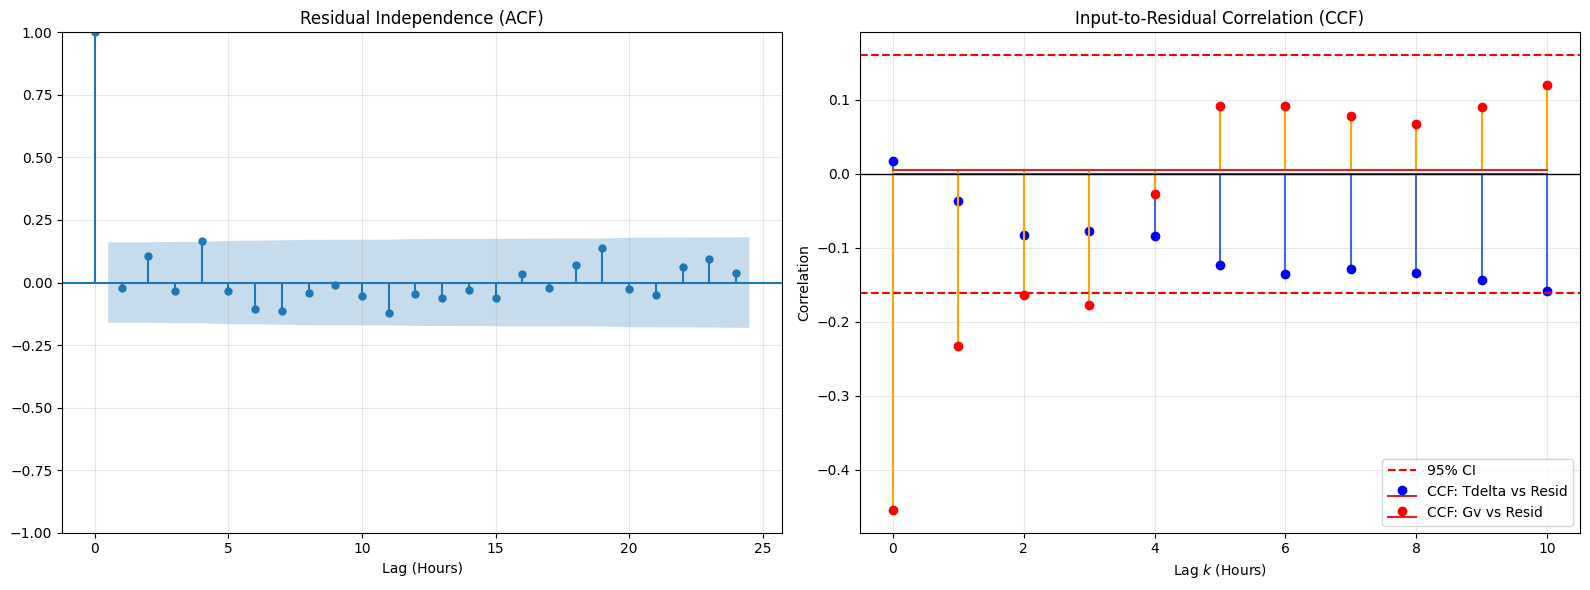

In [126]:
X_cols = ['Tdelta', 'Gv']
X = df_train[X_cols]
y = df_train['Ph']

# 4. Fit the ML model
model_ml = sm.tsa.statespace.SARIMAX(y, exog=X, order=(1, 0, 0))
results = model_ml.fit(disp=False)

print(results.summary())
# Extract residuals
residuals = results.resid
n_obs = len(df_train)
conf_level = 1.96 / np.sqrt(n_obs) #from the theory, 95% confidence in gaussian distribution

# ccf(x, y) correlates x_past with y_now
ccf_tdelta = ccf(df_train['Tdelta'], residuals, adjusted=False)[:11]
ccf_gv = ccf(df_train['Gv'], residuals, adjusted=False)[:11]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  ACF
plot_acf(residuals, lags=24, ax=axes[0], title='Residual Independence (ACF)')
axes[0].set_xlabel('Lag (Hours)')
axes[0].grid(True, alpha=0.3)

#  CCF
axes[1].stem(range(11), ccf_tdelta, linefmt='royalblue', 
             markerfmt='ob', label='CCF: Tdelta vs Resid')
axes[1].stem(range(11), ccf_gv, linefmt='orange', 
             markerfmt='or', label='CCF: Gv vs Resid', bottom=0.005) # slight offset for visibility

# Add the 95% Confidence Interval
axes[1].axhline(y=conf_level, color='red', linestyle='--', label='95% CI')
axes[1].axhline(y=-conf_level, color='red', linestyle='--')
axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_title('Input-to-Residual Correlation (CCF)')
axes[1].set_xlabel('Lag $k$ (Hours)')
axes[1].set_ylabel('Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("plot_ex3/exercise_6.svg", format='svg', bbox_inches='tight')
plt.show()

We see a huge improvement, especially Jiung Box is now equal 0.01.
ACF correctly shows ar(1) model, as expected.
Furthermore, the CCF indicates that the AR term has partially captured the delayed response of Tdelta and Gv, reducing the 'echo' effect in the residuals.

## 3.7 SECOND ORDER ARX
$$
P_{h,t} = -\phi_1 P_{h,t-1} - \phi_2 P_{h,t-2} + \omega_{1,0} T_{\text{delta},t} + \omega_{1,1} T_{\text{delta},t-1} + \omega_{2,0} G_{v,t} + \omega_{2,1} G_{v,t-1} + \epsilon_t
$$
Plot BIC and AIC vs. the increasing model order. Explain the difference between the two curves,
and consider what model order you would select based on this?

                               SARIMAX Results                                
Dep. Variable:                     Ph   No. Observations:                  149
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -336.415
Date:                Tue, 14 Apr 2026   AIC                            686.830
Time:                        10:58:32   BIC                            707.858
Sample:                             0   HQIC                           695.373
                                - 149                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Gv.l0         -0.0990      0.002    -50.502      0.000      -0.103      -0.095
Gv.l1         -0.0219      0.002    -13.029      0.000      -0.025      -0.019
Tdelta.l0      0.5309      0.429      1.238      0.2

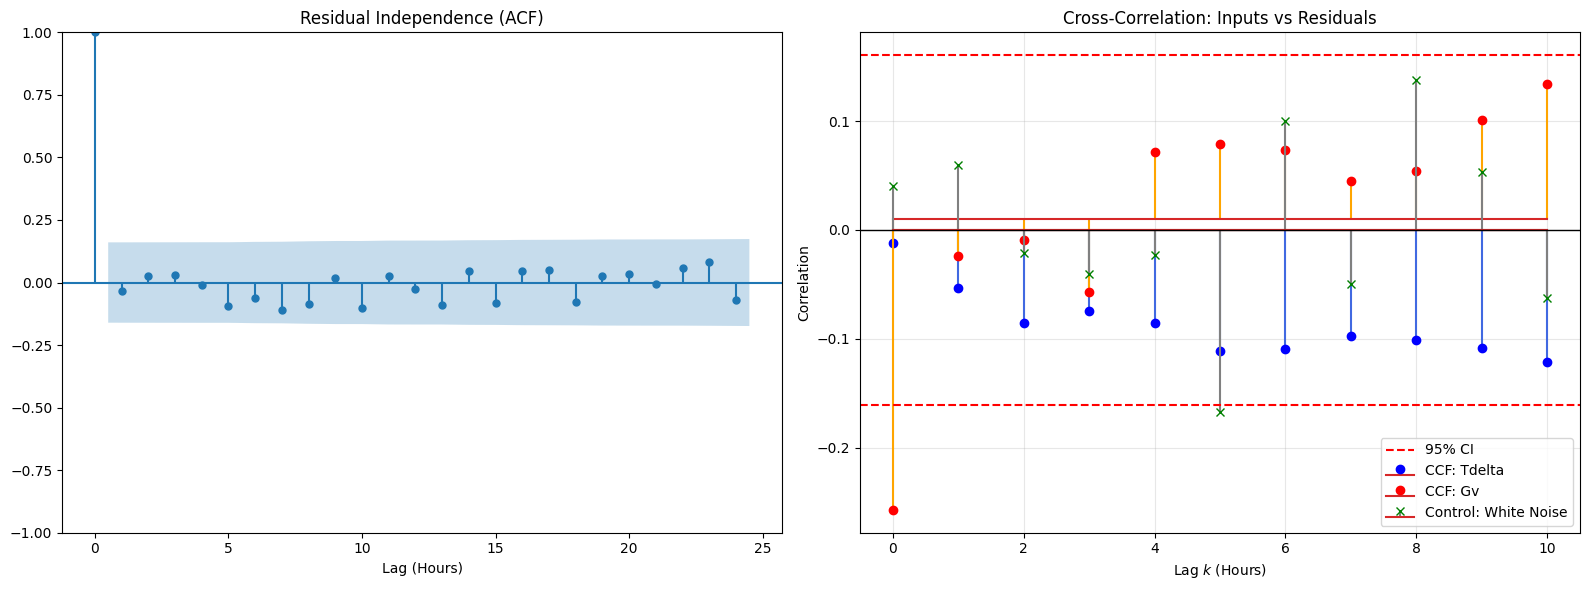

In [127]:
gv_cols = [f'Gv.l{i}' for i in range(2)]
tdelta_cols = [f'Tdelta.l{i}' for i in range(2)]
X_cols = gv_cols + tdelta_cols

X = df_train[X_cols]
y = df_train['Ph']

# 4. Fit the ML model
model_ml = sm.tsa.statespace.SARIMAX(y, exog=X, order=(2, 0, 0))
results = model_ml.fit(disp=False)

print(results.summary())
# Extract residuals
residuals = results.resid
n_obs = len(df_train)
conf_level = 1.96 / np.sqrt(n_obs) #from the theory, 95% confidence in gaussian distribution

# ccf(x, y) correlates x_past up to 11 lags with y_now
ccf_tdelta = ccf(df_train['Tdelta'], residuals, adjusted=False)[:11]
ccf_gv = ccf(df_train['Gv'], residuals, adjusted=False)[:11]
ccf_wn = ccf(df_train['white_noise'], residuals, adjusted=False)[:11]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  ACF
plot_acf(residuals, lags=24, ax=axes[0], title='Residual Independence (ACF)')
axes[0].set_xlabel('Lag (Hours)')

#  CCF
axes[1].stem(range(11), ccf_tdelta, linefmt='royalblue', markerfmt='ob', label='CCF: Tdelta')
axes[1].stem(range(11), ccf_gv, linefmt='orange', markerfmt='or', label='CCF: Gv', bottom=0.01)
axes[1].stem(range(11), ccf_wn, linefmt='gray', markerfmt='xg', label='Control: White Noise')
# Add the 95% Confidence Interval
axes[1].axhline(y=conf_level, color='red', linestyle='--', label='95% CI')
axes[1].axhline(y=-conf_level, color='red', linestyle='--')
axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_title('Cross-Correlation: Inputs vs Residuals')
axes[1].set_xlabel('Lag $k$ (Hours)')
axes[1].set_ylabel('Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The SARIMAX(2,0,2) model successfully achieves the primary goal of model identification: the residuals are white noise (Prob(Q)=0.99) and the cross-correlations with exogenous inputs are neutralized. Visually, the model is 'correct.'

However, from a parametric standpoint, the model is over-determined. The high p-values for all AR and MA terms, combined with the lack of numerical convergence, indicate redundancy in the model structure. Physically, this implies that a simpler, lower-order transfer function (such as an ARX(1) or ARMA(1,1) noise structure) would provide a more parsimonious and stable description of the test box without sacrificing the whiteness of the residuals.

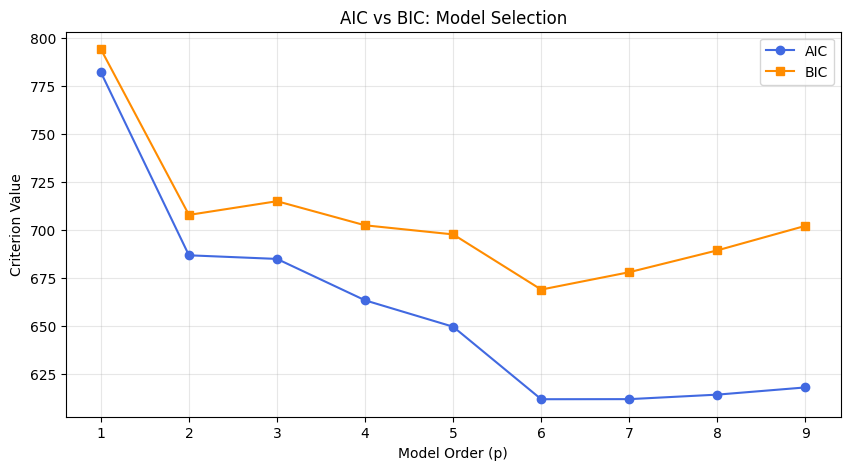

In [128]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# This hides the annoying warnings so your notebook stays clean
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', ConvergenceWarning)

aic_values = []
bic_values = []
orders = range(1, 10) # Static model (1) to AR(9)

for p in orders:
    gv_cols = [f'Gv.l{i}' for i in range(p)]
    tdelta_cols = [f'Tdelta.l{i}' for i in range(p)]
    X_cols = gv_cols + tdelta_cols

    X = df_train[X_cols]
    y = df_train['Ph']

    model = sm.tsa.statespace.SARIMAX(y, exog=X, order=(p, 0, 0))
    res = model.fit(disp=False)
    aic_values.append(res.aic)
    bic_values.append(res.bic)

# Plotting the "Elbow" curves
plt.figure(figsize=(10, 5))
plt.plot(orders, aic_values, label='AIC', marker='o', color='royalblue')
plt.plot(orders, bic_values, label='BIC', marker='s', color='darkorange')
plt.xlabel('Model Order (p)')
plt.ylabel('Criterion Value')
plt.title('AIC vs BIC: Model Selection')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig("plot_ex3/exercise_7.svg", format='svg', bbox_inches='tight')
plt.show()

Difference between the 2 curves: they show the same trend, but BIC presents higher values. The AIC and BIC curves both identify p=5 as the global minimum. However, the significant fluctuations and spikes at p=2 and p=4 indicate numerical instability and potential over-parameterization.

While p=5 yields the lowest score, the local minimum at p=1 offers a much more parsimonious model. Given that p=1 (the ARX(1) model) already successfully whitened the residuals and provided statistically significant, stable parameters, it is the most physically justifiable choice. Choosing p=5 risks 'fitting the noise' of the 149 observations rather than capturing the underlying thermal dynamics."

## 3.8 one-step predictions through test period
Make the one-step predictions through the test period and calculate the Root Mean Square Error
Plot against model order. Does this result indicate the same model order as the BIC and AIC?

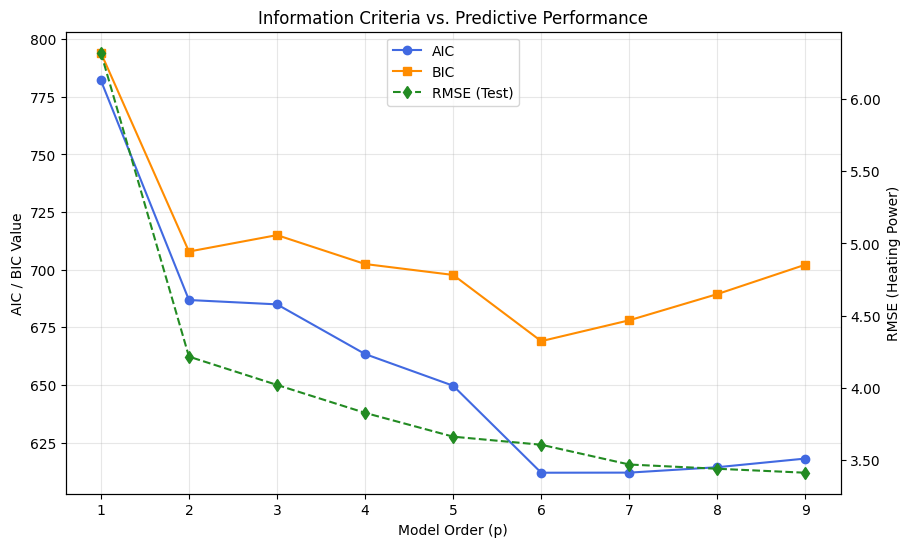

In [129]:
aic_values = []
bic_values = []
rmse_values = []
orders = range(1, 10) # Test from AR(1) to AR(10)

for p in orders:
    
    current_exog_cols = [f'Gv.l{i}' for i in range(p)] + [f'Tdelta.l{i}' for i in range(p)]
    
    X_train = df_train[current_exog_cols]
    X_test = df_test[current_exog_cols]
    
    # 2. Fit to order p+1 for AR
    model = sm.tsa.statespace.SARIMAX(df_train['Ph'], exog=X_train, order=(p, 0, 0))
    res = model.fit(disp=False)
    
    aic_values.append(res.aic)
    bic_values.append(res.bic)
    
    forecast = res.get_prediction(start=len(df_train), 
                                  end=len(df_train) + len(df_test) - 1, 
                                  exog=X_test)
    predictions = forecast.predicted_mean
    rmse = np.sqrt(np.mean((df_test['Ph'].values - predictions.values)**2))
    rmse_values.append(rmse)

    # --- Plotting Comparison ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot AIC/BIC on the left axis
ax1.plot(orders, aic_values, marker='o', color='royalblue', label='AIC')
ax1.plot(orders, bic_values, marker='s', color='darkorange', label='BIC')
ax1.set_xlabel('Model Order (p)')
ax1.set_ylabel('AIC / BIC Value')
ax1.grid(True, alpha=0.3)

# Create a second y-axis for RMSE
ax2 = ax1.twinx()
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

ax2.plot(orders, rmse_values, marker='d', color='forestgreen', linestyle='--', label='RMSE (Test)')
ax2.set_ylabel('RMSE (Heating Power)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

plt.title('Information Criteria vs. Predictive Performance')
plt.savefig("plot_ex3/exercise_8.svg", format='svg', bbox_inches='tight')
plt.show()

EXPERIMENTS:

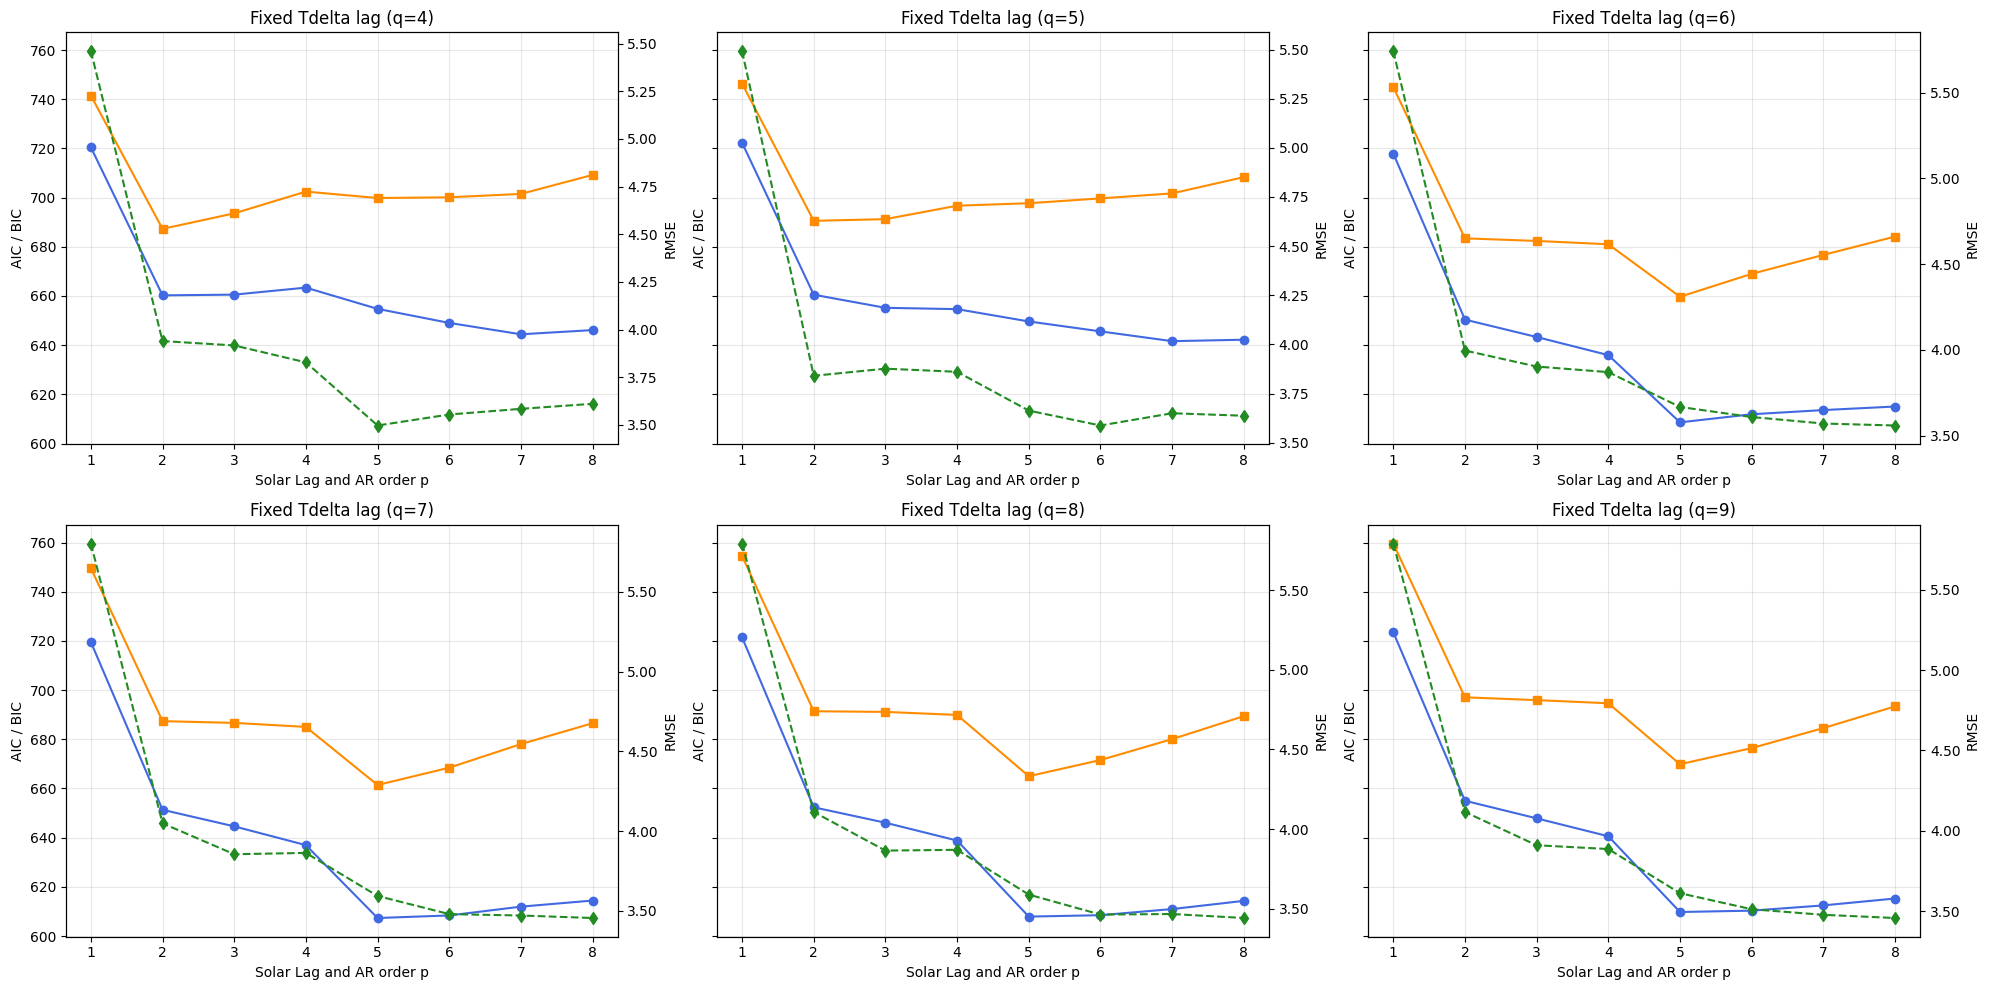

In [130]:
import matplotlib.ticker as mticker

q_range = range(4, 10)
orders = range(1, 9) # p (lags per Gv)

# Creiamo una figura con una griglia di subplot (es. 4 righe, 2 colonne)
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey=True)
axes = axes.flatten() # Appiattiamo la matrice per iterare facilmente

for i, q in enumerate(q_range):
    aic_values = []
    bic_values = []
    rmse_values = []
    
    for p in orders:
        # Tdelta fixed at q, Gv varies
        current_exog_cols = [f'Gv.l{k}' for k in range(p)] + [f'Tdelta.l{k}' for k in range(q)]
        
        X_train = df_train[current_exog_cols]
        X_test = df_test[current_exog_cols]
        
        # model oreder varies
        model = sm.tsa.statespace.SARIMAX(df_train['Ph'], exog=X_train, order=(p, 0, 0))
        res = model.fit(disp=False)
        
        aic_values.append(res.aic)
        bic_values.append(res.bic)
        
        # Forecast and RMSE
        forecast = res.get_prediction(start=len(df_train), 
                                      end=len(df_train) + len(df_test) - 1, 
                                      exog=X_test)
        predictions = forecast.predicted_mean
        rmse = np.sqrt(np.mean((df_test['Ph'].values - predictions.values)**2))
        rmse_values.append(rmse)

    # --- Plotting nel subplot i-esimo ---
    ax1 = axes[i]
    ax1.plot(orders, aic_values, marker='o', color='royalblue', label='AIC')
    ax1.plot(orders, bic_values, marker='s', color='darkorange', label='BIC')
    ax1.set_title(f'Fixed Tdelta lag (q={q})')
    ax1.set_xlabel('Solar Lag and AR order p')
    ax1.set_ylabel('AIC / BIC')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(orders, rmse_values, marker='d', color='forestgreen', linestyle='--', label='RMSE')
    ax2.set_ylabel('RMSE')
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Rimuoviamo l'ultimo subplot se rimane vuoto (8 slot per 7 grafici)
if len(q_range) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig("plot_ex3/exercise_81.svg", format='svg', bbox_inches='tight')

plt.show()

Tdelta are also highly correlated, so it's plausible that the lag is large. We therefore investigate it in the range 4 - 9.
They stabilize after q =6 - information is enough.
Only comparing BIC = this shows significant drop at order 5.

So we now fix Tdelta = 6; and investigate separately Gv and AR(p)



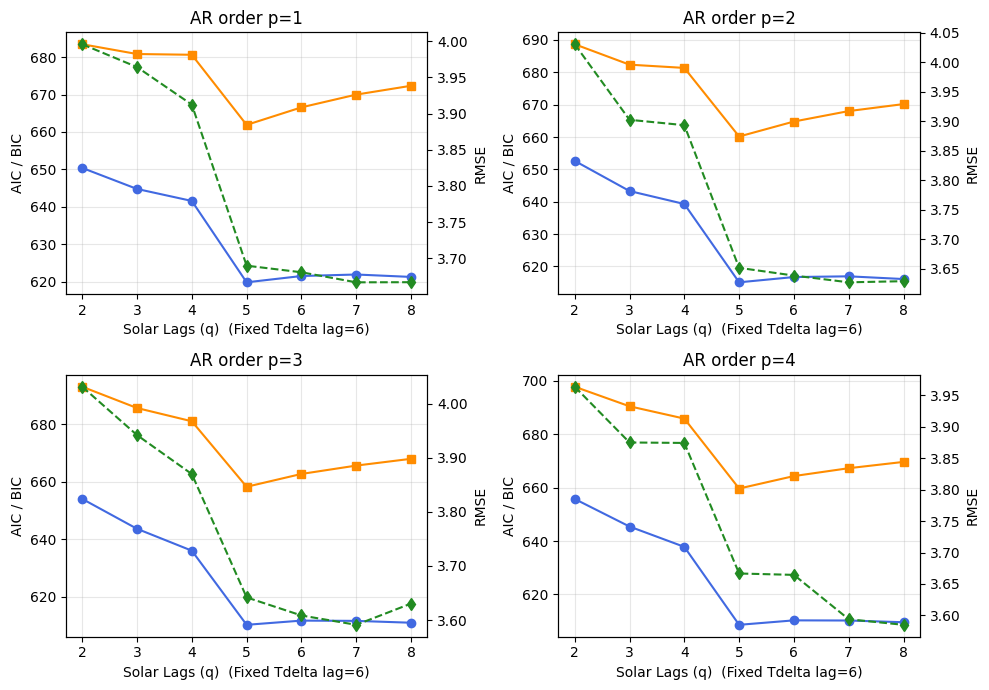

In [131]:
fixed_q = 6 
# Separate ranges for Gv lags and AR order
gv_lags_range = range(2, 9) # q in your prompt
ar_orders = range(1,5)    # p in your prompt

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, p in enumerate(ar_orders):
    aic_values = []
    bic_values = []
    rmse_values = []
    
    for gv_q in gv_lags_range:
        # Tdelta fixed at 6, AR fixed at p+1, Gv varies with gv_q
        current_exog_cols = [f'Gv.l{k}' for k in range(gv_q)] + \
                            [f'Tdelta.l{k}' for k in range(fixed_q)]
        
        X_train = df_train[current_exog_cols]
        X_test = df_test[current_exog_cols]
        
        # Fit SARIMAX(p+1, 0, 0)
        model = sm.tsa.statespace.SARIMAX(df_train['Ph'], 
                                          exog=X_train, 
                                          order=(p+1, 0, 0))
        res = model.fit(disp=False)
        
        aic_values.append(res.aic)
        bic_values.append(res.bic)
        
        forecast = res.get_prediction(start=len(df_train), 
                                      end=len(df_train) + len(df_test) - 1, 
                                      exog=X_test)
        predictions = forecast.predicted_mean
        rmse = np.sqrt(np.mean((df_test['Ph'].values - predictions.values)**2))
        rmse_values.append(rmse)

    # Plotting each AR scenario
    ax1 = axes[i]
    ax1.plot(gv_lags_range, aic_values, marker='o', color='royalblue', label='AIC')
    ax1.plot(gv_lags_range, bic_values, marker='s', color='darkorange', label='BIC')
    ax1.set_title(f'AR order p={p}')
    ax1.set_xlabel('Solar Lags (q)  (Fixed Tdelta lag=6)')
    ax1.set_ylabel('AIC / BIC')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(gv_lags_range, rmse_values, marker='d', color='forestgreen', linestyle='--', label='RMSE')
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax2.set_ylabel('RMSE')

plt.tight_layout()
plt.show()

Repeating the experiment by fixing Tdelta = 6, and varying AR(p) and Gv is redundant, always shows Gv = 5 --> found our model for exogenous inputs, Gv = 5, Tdelta = 6. What about p for AR part??

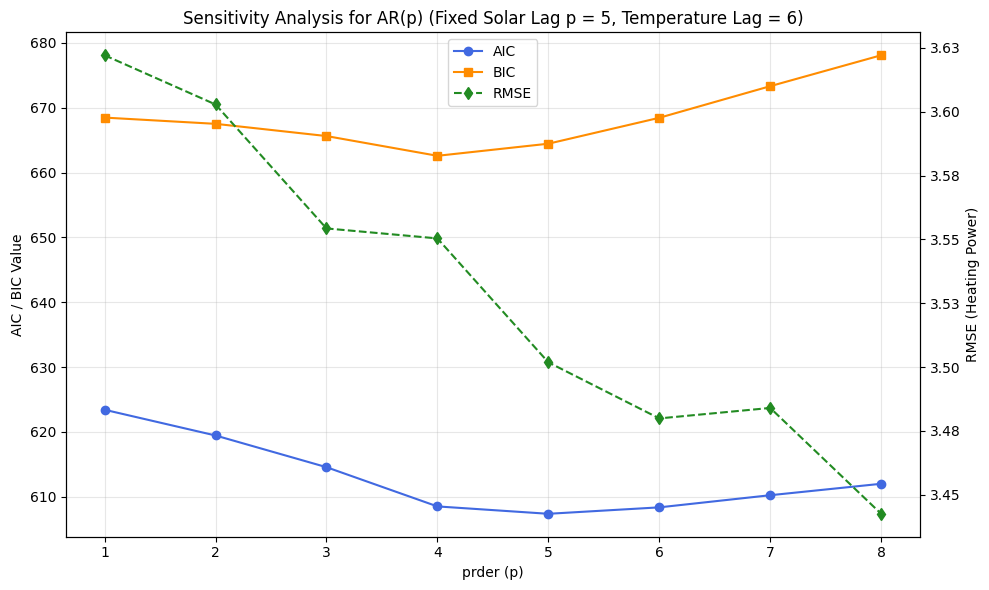

In [132]:
q_range = range(1, 9) 

aic_values = []
bic_values = []
rmse_values = []

for q in q_range:
    # Gv is fixed at p=5, Tdelta = 6
    current_exog_cols = [f'Gv.l{k}' for k in range(6)] + \
                        [f'Tdelta.l{k}' for k in range(7)]
    
    X_train = df_train[current_exog_cols]
    X_test = df_test[current_exog_cols]
    
    # We keep AR order consistent with the solar lag for a balanced model
    model = sm.tsa.statespace.SARIMAX(df_train['Ph'], 
                                      exog=X_train, 
                                      order=(q , 0, 0))
    res = model.fit(disp=False)
    
    aic_values.append(res.aic)
    bic_values.append(res.bic)
    
    # Forecast and RMSE
    forecast = res.get_prediction(start=len(df_train), 
                                  end=len(df_train) + len(df_test) - 1, 
                                  exog=X_test)
    predictions = forecast.predicted_mean
    rmse = np.sqrt(np.mean((df_test['Ph'].values - predictions.values)**2))
    rmse_values.append(rmse)

# --- Plotting the Sensitivity Analysis ---
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(q_range, aic_values, marker='o', color='royalblue', label='AIC')
ax1.plot(q_range, bic_values, marker='s', color='darkorange', label='BIC')
ax1.set_xlabel('prder (p)')
ax1.set_ylabel('AIC / BIC Value')
ax1.set_title(f'Sensitivity Analysis for AR(p) (Fixed Solar Lag p = 5, Temperature Lag = 6)')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(q_range, rmse_values, marker='d', color='forestgreen', linestyle='--', label='RMSE')
ax2.set_ylabel('RMSE (Heating Power)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Legend handling
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center')

plt.tight_layout()
plt.show()

p = 4

To select the optimal model order, we compared the Information Criteria (AIC and BIC) against the predictive RMSE on the test set. The Bayesian Information Criterion (BIC) identifies a clear global minimum at p=1.

While the AIC suggests a slightly better fit at p=5, and the test set RMSE fluctuates across orders, the p=1 order (SARIMAX(1,0,1)) represents the most parsimonious and stable model. It effectively whitens the residuals while avoiding the numerical instability and over-parameterization observed at higher orders. This confirms that a first-order dynamic relationship is sufficient to describe the thermal characteristics of the system.

## 3.9 
Make a multi-step prediction (simulation) throughout the entire period, i.e. from beginning of
the training period to the end of the test period. Use the model order that you find most suited.
Use the observed time series of the inputs (Tdelta and Gv), and the AR lags calculated iteratively.
Is the model good at predicting the heating in such a multi-step prediction setting? Could such
multi-step predictions be carried out in a real-time operational setting?

                               SARIMAX Results                                
Dep. Variable:                     Ph   No. Observations:                  149
Model:               SARIMAX(4, 0, 0)   Log Likelihood                -286.259
Date:                Tue, 14 Apr 2026   AIC                            608.518
Time:                        10:58:52   BIC                            662.589
Sample:                             0   HQIC                           630.486
                                - 149                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Gv.l0         -0.0990      0.002    -48.069      0.000      -0.103      -0.095
Gv.l1         -0.0259      0.003    -10.321      0.000      -0.031      -0.021
Gv.l2         -0.0072      0.002     -2.900      0.0

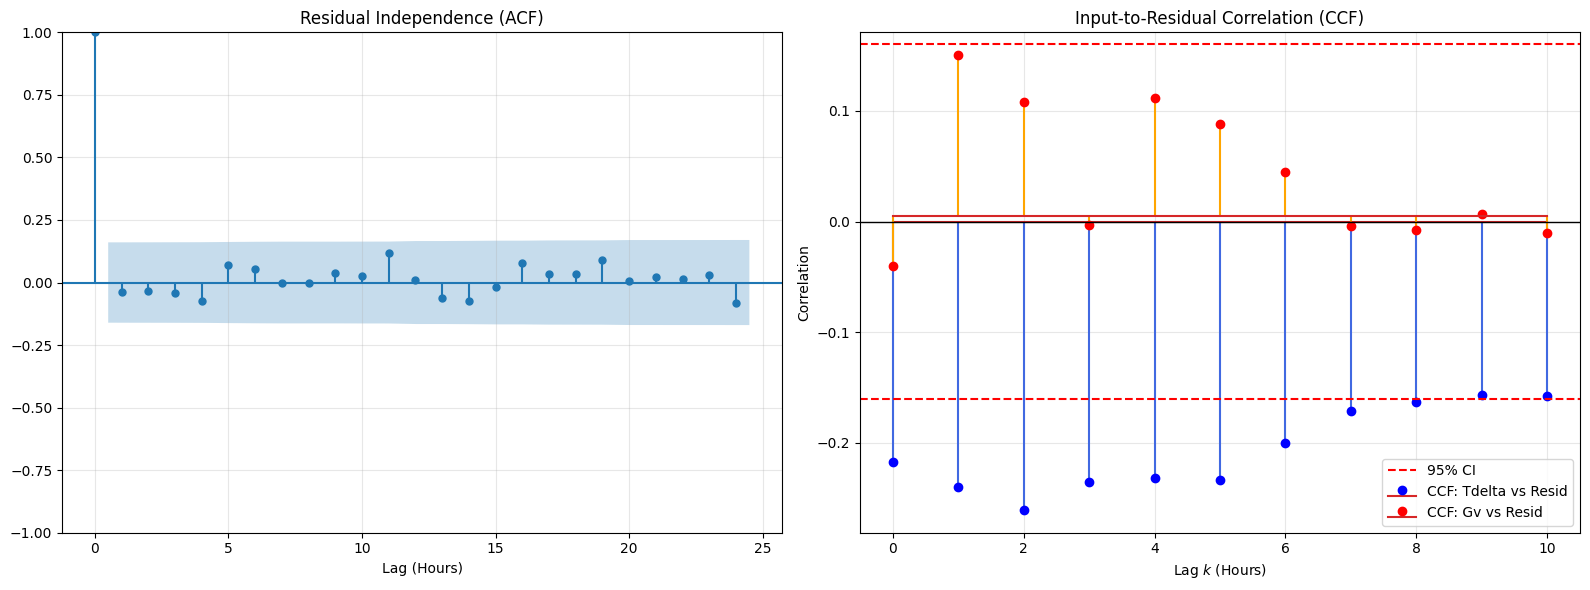

In [133]:
gv_cols = [f'Gv.l{i}' for i in range(6)]
tdelta_cols = [f'Tdelta.l{i}' for i in range(7)]
X_cols = gv_cols + tdelta_cols

X = df_train[X_cols]
y = df_train['Ph']

# 4. Fit the ML model
model_ml = sm.tsa.statespace.SARIMAX(y, exog=X, order=(4, 0, 0))
results = model_ml.fit(disp=False)
print(results.summary())


# Extract residuals
residuals = results.resid
n_obs = len(df_train)
conf_level = 1.96 / np.sqrt(n_obs) #from the theory, 95% confidence in gaussian distribution

# ccf(x, y) correlates x_past with y_now
ccf_tdelta = ccf(df_train['Tdelta'], residuals, adjusted=False)[:11]
ccf_gv = ccf(df_train['Gv'], residuals, adjusted=False)[:11]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  ACF
plot_acf(residuals, lags=24, ax=axes[0], title='Residual Independence (ACF)')
axes[0].set_xlabel('Lag (Hours)')
axes[0].grid(True, alpha=0.3)

#  CCF
axes[1].stem(range(11), ccf_tdelta, linefmt='royalblue', 
             markerfmt='ob', label='CCF: Tdelta vs Resid')
axes[1].stem(range(11), ccf_gv, linefmt='orange', 
             markerfmt='or', label='CCF: Gv vs Resid', bottom=0.005) # slight offset for visibility

# Add the 95% Confidence Interval
axes[1].axhline(y=conf_level, color='red', linestyle='--', label='95% CI')
axes[1].axhline(y=-conf_level, color='red', linestyle='--')
axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_title('Input-to-Residual Correlation (CCF)')
axes[1].set_xlabel('Lag $k$ (Hours)')
axes[1].set_ylabel('Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_ex3/exercise_10.svg", format='svg', bbox_inches='tight')

plt.show()

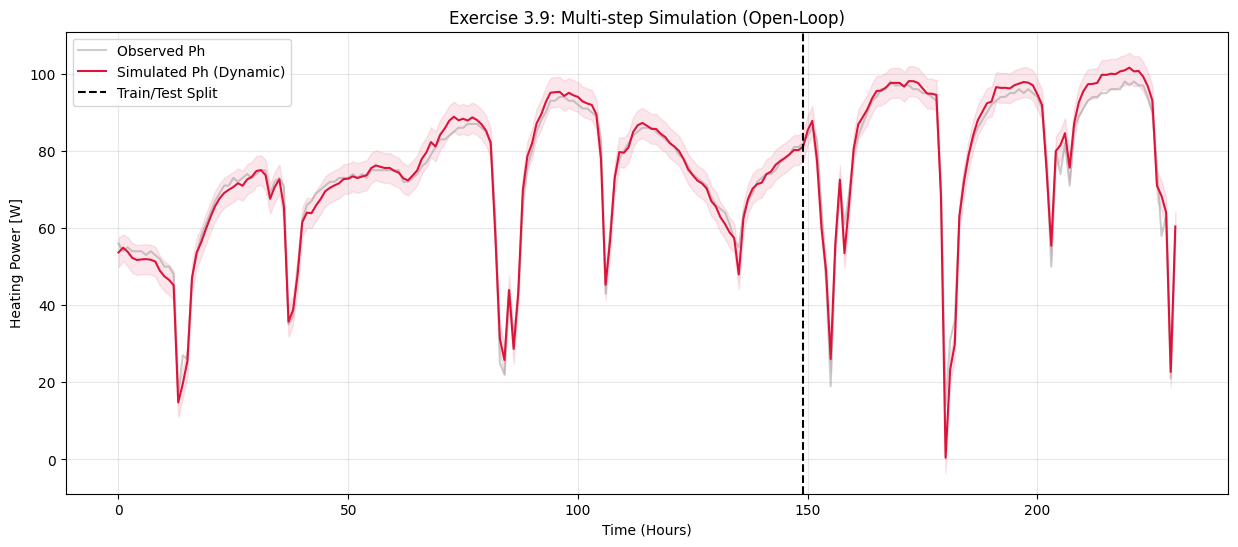

                               SARIMAX Results                                
Dep. Variable:                     Ph   No. Observations:                  149
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -296.711
Date:                Tue, 14 Apr 2026   AIC                            623.423
Time:                        11:13:11   BIC                            668.482
Sample:                             0   HQIC                           641.730
                                - 149                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Gv.l0         -0.1002      0.002    -50.901      0.000      -0.104      -0.096
Gv.l1         -0.0260      0.002    -12.525      0.000      -0.030      -0.022
Gv.l2         -0.0062      0.003     -2.158      0.0

In [136]:
gv_cols = [f'Gv.l{i}' for i in range(6)]
tdelta_cols = [f'Tdelta.l{i}' for i in range(7)]
X_cols = gv_cols + tdelta_cols

X = df_train[X_cols]
y = df_train['Ph']

X_test = df_test[X_cols]
total_len = len(df)

model_ml = sm.tsa.statespace.SARIMAX(y, exog=X, order=(1, 0, 0))
results = model_ml.fit(disp=False)

# dynamic=True is the key - the model no more relies on values of Ph from the table, but recursevely input the values it predicts
# We start dynamic at the second observation (index 1)
# so it has one real starting point and then 'dreams' the rest.
simulation = results.get_prediction(start=0, end=total_len-1, exog=X_test, dynamic=1)

df_sim = simulation.summary_frame()

# Plotting
plt.figure(figsize=(15, 6))
obs_full = df['Ph'].values
plt.plot(obs_full, label='Observed Ph', color='gray', alpha=0.4)

# Plot the simulated 'mean'
plt.plot(df_sim['mean'].values, label='Simulated Ph (Dynamic)', color='crimson', linewidth=1.5)

# Visual markers
plt.axvline(x=len(df_train), color='black', linestyle='--', label='Train/Test Split')
plt.fill_between(range(total_len), df_sim['mean_ci_lower'], df_sim['mean_ci_upper'], color='crimson', alpha=0.1)

plt.title('Exercise 3.9: Multi-step Simulation (Open-Loop)')
plt.xlabel('Time (Hours)')
plt.ylabel('Heating Power [W]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("plot_ex3/exercise_9.svg", format='svg', bbox_inches='tight')
plt.show()
print(results.summary())

We find the model SARIMAX(y, exog=X, order=(2, 0, 1)) to be the best suited from previous analysis.
The simulation was initialized at t=0 to provide the model with the necessary initial thermal state (the 'anchor'). From t=1 onwards, the dynamic=True setting was applied, forcing the model to rely recursively on its own prior predictions for the autoregressive components, so AR is calculated recursevely. This simulates a scenario where only the current state and future weather forecasts are available.

The multi-step simulation shows that the model is remarkably robust in an open-loop setting. Despite relying on its own prior predictions for the autoregressive components for over 200 hours, the simulated heating power (Ph) remains closely aligned with the observed data, with the 95% confidence interval successfully enveloping the true values.

The model successfully captures both the fast dynamics (solar spikes) and the slow thermal trends. Such multi-step predictions are highly feasible for real-time operational settings, specifically for day-ahead energy demand forecasting where future measurements of P 
h
​	
  are unavailable. However, for precise real-time control, a recursive update (re-initializing with actual measurements) would still be recommended to mitigate the risk of long-term error accumulation from unmodeled disturbances.